In [444]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import math
import random
%matplotlib inline
print("Imported Successfully")

Imported Successfully


In [429]:
class Value:
    def __init__(self, data, _children=(), _op = '', label=''):
        self.data = data;
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None
        

    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other, ), _op = '+')
        def _backward():
            self.grad += 1.0 * out.grad;
            other.grad += 1.0 * out.grad;
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self * other
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other, ), _op = '*')
        def _backward():
            self.grad += other.data * out.grad;
            other.grad += self.data * out.grad;
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1;

    def __neg__(self):
        return self * -1;

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = self + (-other);
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad 
        out._backward = _backward
        return out


    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self, ), f'**{other}')
        def _backward():
            self.grad = other * ((self.data)**(other - 1) * out.grad)
        out._backward = _backward
        return out;
    
    def backward(self):
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v);
                
        build_topo(self)
        self.grad = 1
        for node in reversed(topo):
            node._backward()

In [369]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    # dot.node(name = uid, label = "{ %s | data %.4f}" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [370]:
x = Value(2.0, label = 'x')
y = Value(0.0, label = 'y')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.88137, label = 'b')

In [371]:
xw1 = x*w1;                              xw1.label = 'xw1'; 
yw2 = y*w2;                              yw2.label = 'yw2';
xw1yw2 = xw1 + yw2;                      xw1yw2.label = 'xw1yw2'; 
z = xw1yw2 + b;                          z.label = 'z';
o = z.tanh();                            o.label = 'o'
o


Value(data=0.7071049876722272)

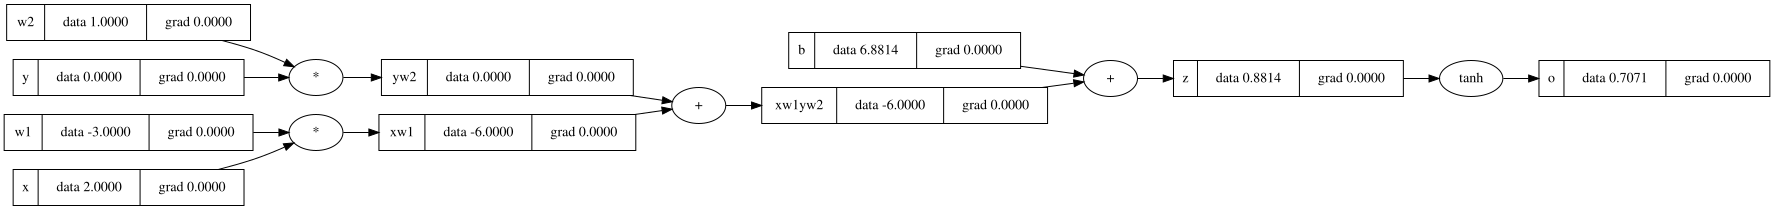

In [372]:
draw_dot(o)

In [373]:
o.grad = 1.0

In [374]:
o._backward()
z._backward()
xw1yw2._backward()
xw1._backward()
yw2._backward()

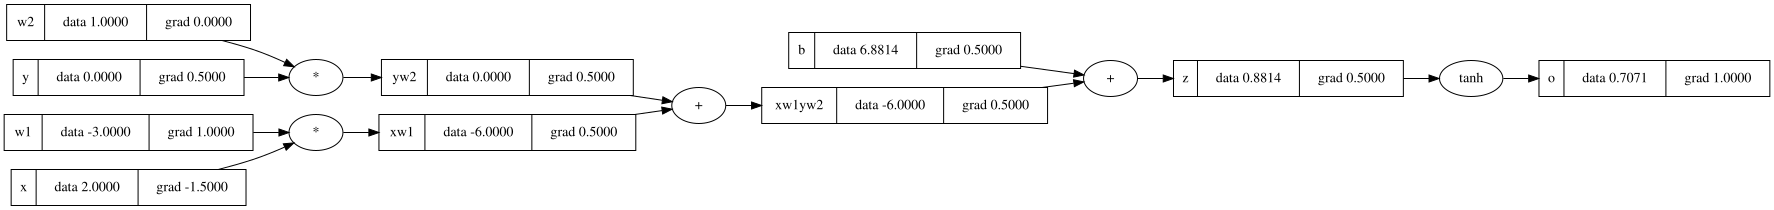

In [375]:
draw_dot(o)

In [389]:
x = Value(2.0, label = 'x')
y = Value(0.0, label = 'y')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.88137, label = 'b')

In [390]:
xw1 = x*w1;                              xw1.label = 'xw1'; 
yw2 = y*w2;                              yw2.label = 'yw2';
xw1yw2 = xw1 + yw2;                      xw1yw2.label = 'xw1yw2'; 
z = xw1yw2 + b;                          z.label = 'z';
o = z.tanh();                            o.label = 'o'
o


Value(data=0.7071049876722272)

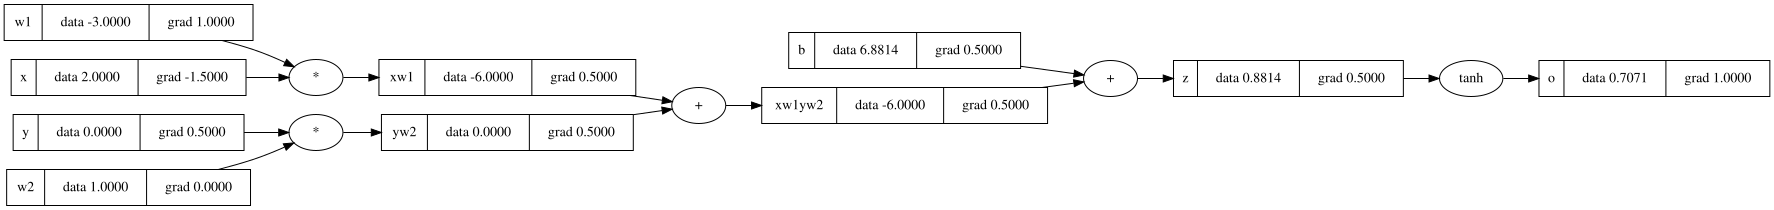

In [393]:
draw_dot(o)

In [392]:
o.backward()

In [430]:
x = Value(2.0, label = 'x')
y = Value(0.0, label = 'y')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.88137, label = 'b')

In [431]:
xw1 = x*w1;                              xw1.label = 'xw1'; 
yw2 = y*w2;                              yw2.label = 'yw2';
xw1yw2 = xw1 + yw2;                      xw1yw2.label = 'xw1yw2'; 
z = xw1yw2 + b;                          z.label = 'z';
e = (2*z).exp();                         e.label = 'e';
o = (e - 1) / (e + 1);                   o.label = 'o'; 

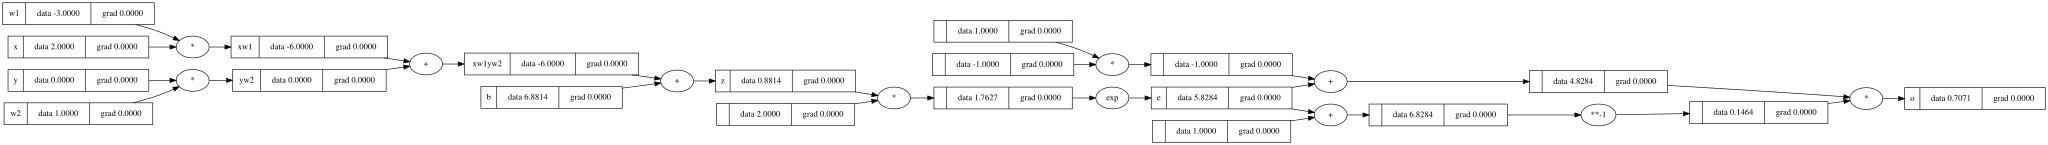

In [432]:
draw_dot(o)

In [433]:
o.backward()

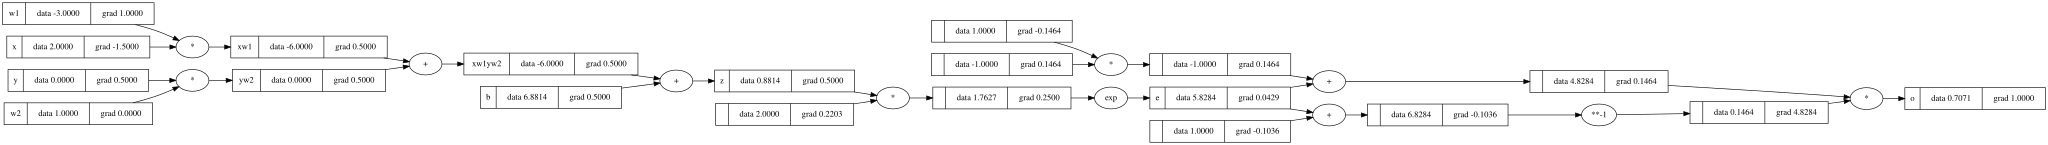

In [434]:
draw_dot(o)

#Pytorch


In [437]:
x1 = torch.tensor([2.0]).double()                      ;x1.requires_grad = True
x2 = torch.tensor([0.0]).double()                      ;x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()                     ;w1.requires_grad = True
w2 = torch.tensor([1.0]).double()                      ;w2.requires_grad = True
b = torch.tensor([6.88137]).double()                   ;b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.item())
o.backward()

print(f"x1 grad is {x1.grad.item()}")
print(f"x2 grad is {x2.grad.item()}")
print(f"w1 grad is {w1.grad.item()}")
print(f"w2 grad is {w2.grad.item()}")
print(f"b grad is {b.grad.item()}")

0.7071050214706146
x1 grad is -1.500007465833125
x2 grad is 0.5000024886110417
w1 grad is 1.0000049772220834
w2 grad is 0.0
b grad is 0.5000024886110417


In [600]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range (nin)]
        self.b = Value(random.uniform(-1, 1))
    def __call__(self, x):
            act = sum((xi * wi for xi, wi in zip(x, self.w)), self.b)
            out = act.tanh()
            return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extends(ps)
        # return params
        
class MLP():
    def __init__(self, nin, nouts):
        sz = [nin] + nouts;
        print(sz)
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x;

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [601]:
X = [2.3, 5.2, -12.3]
n = MLP(3, [4,4,1])
n(X)

[3, 4, 4, 1]


Value(data=-0.5855369266269642)

In [602]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data=0.27084094424980515),
 Value(data=0.26606974728660315),
 Value(data=0.3330238866903206),
 Value(data=0.07235007003723515)]

In [603]:
ypred

[Value(data=0.27084094424980515),
 Value(data=0.26606974728660315),
 Value(data=0.3330238866903206),
 Value(data=0.07235007003723515)]

In [604]:
n.parameters()

[Value(data=0.8861762656288035),
 Value(data=-0.3449496858748575),
 Value(data=0.416214673521087),
 Value(data=0.3564532958715376),
 Value(data=0.4398160935779518),
 Value(data=0.8938256123994621),
 Value(data=-0.3839196879777933),
 Value(data=0.7551711862126125),
 Value(data=-0.6398974348915556),
 Value(data=-0.08807651374115433),
 Value(data=-0.26658181552162663),
 Value(data=-0.9544764314742227),
 Value(data=-0.658970445107401),
 Value(data=-0.024600338619140905),
 Value(data=-0.8741884051392894),
 Value(data=-0.6307730964244789),
 Value(data=0.6010792237790854),
 Value(data=0.8685163669271703),
 Value(data=-0.33383768931213487),
 Value(data=0.3235072074129417),
 Value(data=-0.890075364571981),
 Value(data=0.7528195443649468),
 Value(data=0.9315059168250164),
 Value(data=0.8692327587547819),
 Value(data=0.48423483329236716),
 Value(data=-0.34677956829203826),
 Value(data=0.3996270747079105),
 Value(data=0.19557753620268192),
 Value(data=-0.9560039564922389),
 Value(data=-0.493105094

In [605]:
for k in range (50):
    
    #  forward pass
    ypred = [n(x) for x in xs]
    loss =  sum(((yout - ygt)**2) for ygt,yout in zip(ys, ypred)) 

    # backward pass
    for p in n.parameters():
        p.grad = 0;
    loss.backward()
    
    

    # update
    for p in n.parameters():
        p.data += -0.05 * p. grad

    print(k, loss.data)

0 4.240419680041255
1 2.4039941372355376
2 1.707674485643734
3 1.0607295133578036
4 0.6520207296562427
5 0.4345898951538018
6 0.313689282760214
7 0.2404343583518212
8 0.19253492502759556
9 0.15927178777861498
10 0.1350597599818431
11 0.11676815975441315
12 0.10253004371985422
13 0.09117310325347544
14 0.08192877800758475
15 0.07427457667105088
16 0.06784416163482432
17 0.06237378623663762
18 0.05766915751298551
19 0.053584248696230935
20 0.05000735497833442
21 0.04685167911739192
22 0.044048829581867836
23 0.04154423824944134
24 0.03929387159413637
25 0.03726183109105598
26 0.035418576090389
27 0.03373958966841147
28 0.032204364498692926
29 0.030795623125814804
30 0.02949871212155812
31 0.028301126747787026
32 0.02719213463750146
33 0.026162475362298272
34 0.025204118705077272
35 0.024310068744886885
36 0.02347420398539092
37 0.02269114605904053
38 0.021956151249532593
39 0.02126502035858157
40 0.02061402341436789
41 0.01999983646014039
42 0.01941948823125135
43 0.018870314970173496
44

In [606]:
ypred

[Value(data=0.944557836924066),
 Value(data=-0.9555742567909157),
 Value(data=-0.9215353325742448),
 Value(data=0.9106660434364187)]

In [607]:
import os
print(os.getcwd())

/home/aman-saleem


In [608]:
print(os.listdir())

['clipflow-safe-run.log', '.shell.pre-oh-my-zsh', '.bash_logout', '.wget-hsts', '.vscode-shared', '.ipynb_checkpoints', 'DaVinci Resolve Media', '.antigravity', 'package-lock.json', '.npm', 'Public', '.xinputrc', '.config', '.dotnet', '.zshrc', '.opencode', 'Downloads', '.gemini', '.zshenv', '.openwhispr', '.pki', '.tmux.conf', '.gnupg', '.bash_history', '.sudo_as_admin_successful', 'kubectl.sha256', 'jupyter-env', 'snap', 'Pictures', 'Videos', '.codex', '.node_repl_history', '.python_history', '.cursor', '.vimrc', '.zcompdump-aman-saleem-IdeaPad-Gaming-3-15IMH05-5.9.zwc', 'IdeaProjects', '.password-store', '.antigravity-ide', '.claude.json.backup.1775058315029', '.claude.json', '.nvm', '.cargo', '.mongodb', '.local', '.profile', '.claude.json.backup', '.zcompdump-aman-saleem-IdeaPad-Gaming-3-15IMH05-5.9', 'malicious.exe', 'Desktop', '.bun', 'node_modules', 'Documents', '.jupyter', '.kube', 'micrograd.ipynb', '.zcompdump', '.nv', '.claude', '.gitconfig', '.vscode', '.ipython', '.claude